# Module A: Accelerometer

# Module B: Gyroscope

# Module C: Magnetometer

### C.1 Load in the data collected:

In [1]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec


path = '4_13_26\C2.HardSoftIron.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 617 samples


### C.2 Plot the raw data 

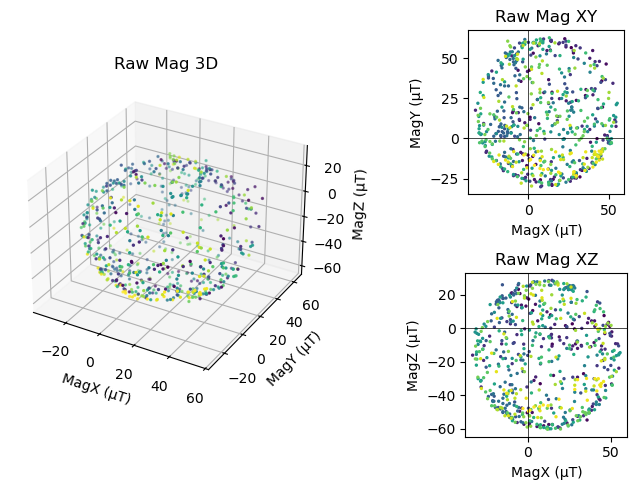

In [2]:
fig = plt.figure(figsize=(8, 5))  # slightly wider overall
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # RIGHT side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx, my, s=2, c=t, cmap='viridis')
ax_xy.set_aspect('equal')
ax_xy.set_title('Raw Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx, mz, s=2, c=t, cmap='viridis')
ax_xz.set_aspect('equal')
ax_xz.set_title('Raw Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

### C.3 Compute the Hard offsets

In [3]:
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

offset_x = (mx_max + mx_min) / 2
offset_y = (my_max + my_min) / 2
offset_z = (mz_max + mz_min) / 2

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')
print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

MagX range: -33.00 to 55.35 µT
MagY range: -30.15 to 62.70 µT
MagZ range: -60.45 to 28.80 µT
Hard iron offsets: X=11.175, Y=16.275, Z=-15.825 µT


### C.4 Calibrate with the Hard Offsets solved for and plot it:

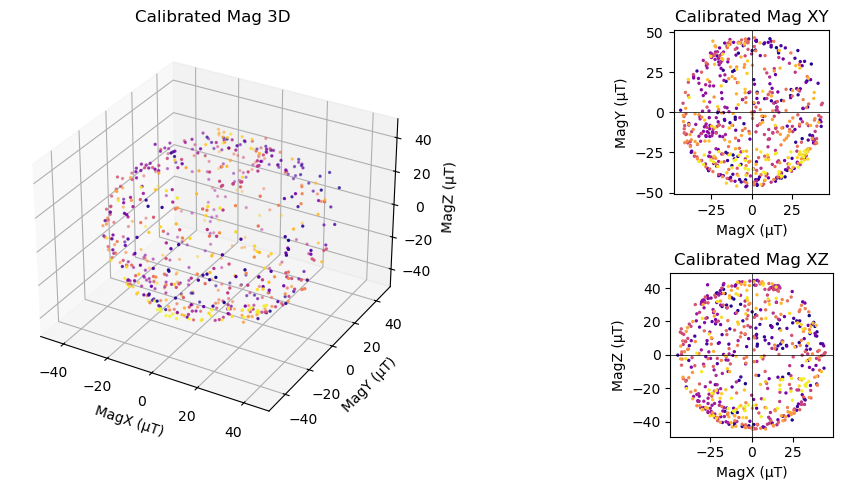

In [4]:
mx_cal = [x - offset_x for x in mx]
my_cal = [y - offset_y for y in my]
mz_cal = [z - offset_z for z in mz]

# --- Figure layout ---
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # right side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
ax_xy.set_aspect('equal')
ax_xy.set_title('Calibrated Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
ax_xz.set_aspect('equal')
ax_xz.set_title('Calibrated Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

### Writeup 

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |   11.175    |
| Y    |   16.275    |
| Z    |  -15.825    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
    1A. After calibration, the 3D scatter plot looks like an elongated sphere. This is due to the offsets simply translating the sphere to the origin but does not account for scaling or distortion so each axis could be slightly more sensitive than others. As shown in the plot, the Magnitude range differs per axis further validating a soft-iron correction could be necessary. 
    
2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
    For recorded raw data, it can be seen in the XY and XZ plots that there is generally good coverage in each orientation. Looking closely at the XY plot, there's some blank areas slightly below the horizontal axis, and in the upper right corner. In the XZ plot, there's a horizontal gap from about Z=-20 to -30. 
    
3. What happens to your heading estimate if you skip calibration?
    As seen in the raw data plots, the plotted points create a sphere whose center is not at the origin. This means that the heading is not pointing in the right direction. By skipping calibration, this error in the heading estimate would not be accounted for. By adjusting with the hard iron offsets, the data is calibrated such that the data is plotted with the center at the origin. 
    

# Extra Credit

### Explore the soft iron calibration for the magnetometer.

Since my plot from the Hard-iron Calibration is distorted, it demonstrates a need for soft iron calibration. Soft-Iron calibration corrects distortion for axis sensitivity and cross-axis coupling. 

Below, least square optimization was utilized as it minimizes the overall error in the non-linear model. It provides the an estimation based on noise assumptions and is efficient for this use-case as it balances accuracy and robustness by handling offsets and scaling effects. 

In [ ]:
from scipy.optimize import least_squares
import numpy as np

data = np.column_stack([mx, my, mz])
def unpack_params(p):
    c = p[:3]
    # lower-triangular L
    l11, l21, l22, l31, l32, l33 = p[3:]
    L = np.array([
        [l11, 0.0, 0.0],
        [l21, l22, 0.0],
        [l31, l32, l33]
    ])
    return c, L

def residuals(p, X):
    c, L = unpack_params(p)
    Xc = X - c
    Y = (L @ Xc.T).T
    r = np.sqrt(np.sum(Y**2, axis=1))
    return r - 1.0

# Initial guess:
c0 = np.mean(data, axis=0)

# Use covariance to get a reasonable initial scaling
X0 = data - c0
cov0 = np.cov(X0, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov0)
eigvals = np.maximum(eigvals, 1e-12)

# initial transform ~ inverse sqrt covariance
W0 = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

# convert W0 to lower-triangular form via Cholesky of W0.T @ W0
M0 = W0.T @ W0
L0 = np.linalg.cholesky(M0)

p0 = np.array([
    c0[0], c0[1], c0[2],
    L0[0, 0], L0[1, 0], L0[1, 1], L0[2, 0], L0[2, 1], L0[2, 2]
])

# Fit
result = least_squares(residuals, p0, args=(data,))
p_fit = result.x
center, L = unpack_params(p_fit)

# Apply calibration
data_centered = data - center
corrected = (L @ data_centered.T).T

r = np.linalg.norm(corrected, axis=1)
corrected = corrected / np.mean(r)

mx_fit = corrected[:, 0]
my_fit = corrected[:, 1]
mz_fit = corrected[:, 2]

print("Estimated hard-iron center:")
print(center)
print("\nEstimated soft-iron correction matrix L:")
print(L)

print("\nmeans:", np.mean(mx_fit), np.mean(my_fit), np.mean(mz_fit))
print("stds :", np.std(mx_fit), np.std(my_fit), np.std(mz_fit))
print("radius mean/min/max:", np.mean(np.linalg.norm(corrected, axis=1)),
      np.min(np.linalg.norm(corrected, axis=1)),
      np.max(np.linalg.norm(corrected, axis=1)))



Estimated hard-iron center:
[ 10.87375696  16.57413785 -15.55436006]

Estimated soft-iron correction matrix L:
[[ 0.02301542  0.          0.        ]
 [-0.00010772  0.02188851  0.        ]
 [ 0.00036611 -0.00069845  0.02270282]]

means: -0.018277621377139074 -0.10394760168330888 -0.022980098749925886
stds : 0.529912822865282 0.5800190661555314 0.6099873579782727
radius mean/min/max: 1.0 0.7778183545169742 1.1632429187009024


### Plot of the Soft-Iron Calibration based on Least-Square Approximation

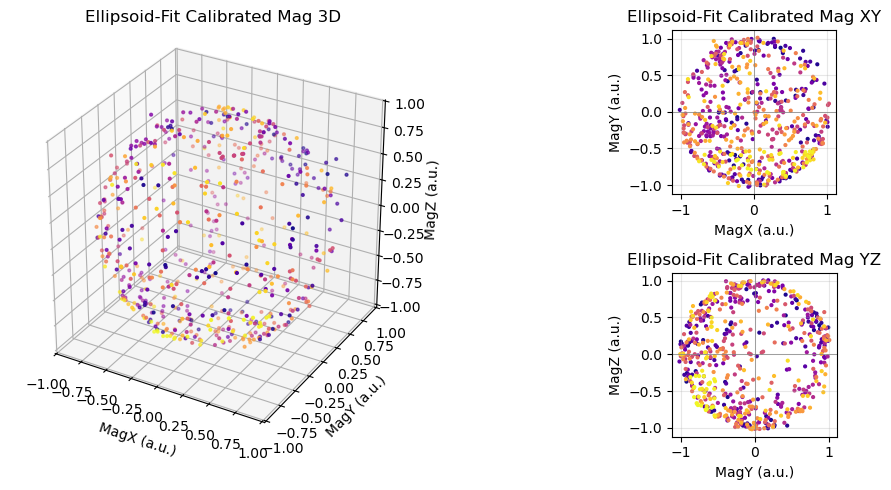

In [ ]:

fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, width_ratios=[1, 1.5])

# 3D
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx_fit, my_fit, mz_fit, s=4, c=t, cmap='plasma')
ax3d.set_title('Ellipsoid-Fit Calibrated Mag 3D')
ax3d.set_xlabel('MagX (a.u.)')
ax3d.set_ylabel('MagY (a.u.)')
ax3d.set_zlabel('MagZ (a.u.)')

xlim = [np.min(mx_fit), np.max(mx_fit)]
ylim = [np.min(my_fit), np.max(my_fit)]
zlim = [np.min(mz_fit), np.max(mz_fit)]

max_range = max(xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]) / 2
xmid = np.mean(xlim)
ymid = np.mean(ylim)
zmid = np.mean(zlim)

ax3d.set_xlim(xmid - max_range, xmid + max_range)
ax3d.set_ylim(ymid - max_range, ymid + max_range)
ax3d.set_zlim(zmid - max_range, zmid + max_range)
ax3d.set_box_aspect((1, 1, 1))

# XY
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx_fit, my_fit, s=4, c=t, cmap='plasma')
ax_xy.set_aspect('equal')
ax_xy.set_title('Ellipsoid-Fit Calibrated Mag XY')
ax_xy.set_xlabel('MagX (a.u.)')
ax_xy.set_ylabel('MagY (a.u.)')
ax_xy.axhline(0, color='gray', lw=0.5)
ax_xy.axvline(0, color='gray', lw=0.5)
ax_xy.grid(True, alpha=0.3)

# YZ
ax_yz = fig.add_subplot(gs[1, 1])
ax_yz.scatter(my_fit, mz_fit, s=4, c=t, cmap='plasma')
ax_yz.set_aspect('equal')
ax_yz.set_title('Ellipsoid-Fit Calibrated Mag YZ')
ax_yz.set_xlabel('MagY (a.u.)')
ax_yz.set_ylabel('MagZ (a.u.)')
ax_yz.axhline(0, color='gray', lw=0.5)
ax_yz.axvline(0, color='gray', lw=0.5)
ax_yz.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As shown above, the least-square approximation scales the ellipse into a unit sphere. This addresses the scaling issue while implementing the translational changes due to the hard-iron calibration. AI helped me implement the least-square approximation and generate code that I was able to use with our collected data.